# Duplicates & Outliers

Two other critical data quality problems: duplicate records inflate counts and bias statistics; outliers distort means and can derail ML models.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print("Shape:", df.shape)

Shape: (891, 15)


---
## Part 1: Duplicate Records

### Why duplicates occur
- Merging data from multiple sources/files
- Manual data entry mistakes
- System glitches during data capture or transmission

### Why duplicates are harmful
- Inflate counts and distort means
- Cause ML models to overfit (model memorises repeated rows)
- Waste computational resources

In [2]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Simulate duplicates
df_with_dupes = pd.concat([df, df.iloc[:30]], ignore_index=True)
print(f"After adding 30 artificial duplicates: {df_with_dupes.duplicated().sum()} duplicates")

# Show the duplicated rows
print("\nExample duplicated rows:")
df_with_dupes[df_with_dupes.duplicated(keep=False)].head(6)

Duplicate rows: 107
After adding 30 artificial duplicates: 137 duplicates

Example duplicated rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True


Fare mean — original:           32.20
Fare mean — with duplicates:    32.09



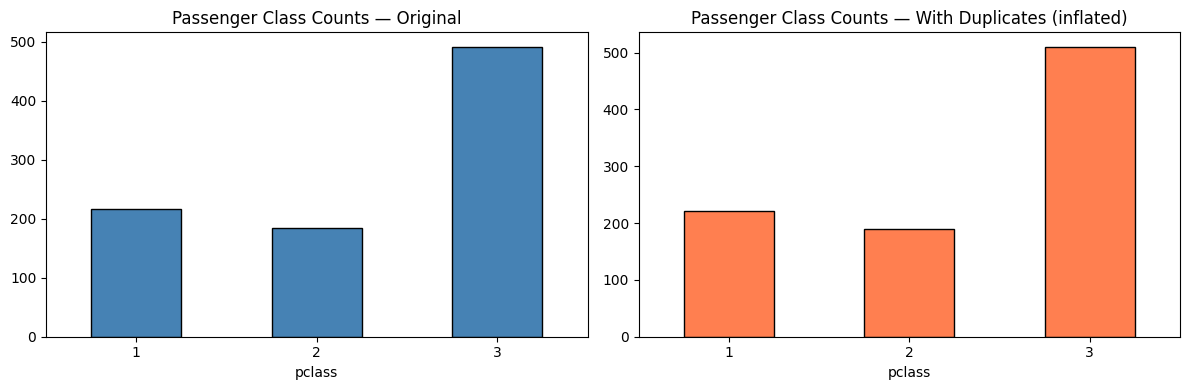

In [3]:
# Effect of duplicates on statistics
print("Fare mean — original:           {:.2f}".format(df['fare'].mean()))
print("Fare mean — with duplicates:    {:.2f}".format(df_with_dupes['fare'].mean()))
print()

# Count plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['pclass'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Passenger Class Counts — Original')
axes[0].tick_params(rotation=0)

df_with_dupes['pclass'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Passenger Class Counts — With Duplicates (inflated)')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

In [4]:
# Remove duplicates
# keep='first'  → retain first occurrence
# keep='last'   → retain last occurrence
# keep=False    → drop all copies of duplicated rows

df_deduped = df_with_dupes.drop_duplicates(keep='first')
print(f"Before: {len(df_with_dupes):4d} rows")
print(f"After:  {len(df_deduped):4d} rows")
print(f"Remaining duplicates: {df_deduped.duplicated().sum()}")

Before:  921 rows
After:   784 rows
Remaining duplicates: 0


---
## Part 2: Outliers

Outliers are data points that differ significantly from the rest of the dataset.

### Why outliers are harmful
- **Statistical distortion**: pull means, inflate variances, skew distributions
- **Model degradation**: distance-based algorithms (KNN, SVM) are particularly sensitive
- **Misleading insights**: a single extreme value can dominate a visualization

> **Not all outliers are errors** — sometimes they represent real, important events (fraud, record-breaking observations).

### Detection Method 1: Z-Score

Measures how many standard deviations a point is from the mean:

$$z = \frac{x - \mu}{\sigma}$$

Rule: **|z| > 3** → potential outlier.  
Assumes approximately normal distribution.

In [5]:
df_clean = df.dropna(subset=['age', 'fare']).copy()

# Z-scores
df_clean['age_z']  = np.abs(zscore(df_clean['age']))
df_clean['fare_z'] = np.abs(zscore(df_clean['fare']))

print("Outliers by Z-score (|z| > 3):")
print(f"  age:  {(df_clean['age_z'] > 3).sum()} outliers")
print(f"  fare: {(df_clean['fare_z'] > 3).sum()} outliers")
print()
print("Fare outliers:")
print(df_clean[df_clean['fare_z'] > 3][['fare', 'fare_z']].sort_values('fare', ascending=False))

Outliers by Z-score (|z| > 3):
  age:  2 outliers
  fare: 18 outliers

Fare outliers:
         fare    fare_z
679  512.3292  9.032109
258  512.3292  9.032109
737  512.3292  9.032109
27   263.0000  4.317274
88   263.0000  4.317274
341  263.0000  4.317274
438  263.0000  4.317274
742  262.3750  4.305455
311  262.3750  4.305455
299  247.5208  4.024561
118  247.5208  4.024561
380  227.5250  3.646439
716  227.5250  3.646439
700  227.5250  3.646439
377  211.5000  3.343405
689  211.3375  3.340332
730  211.3375  3.340332
779  211.3375  3.340332


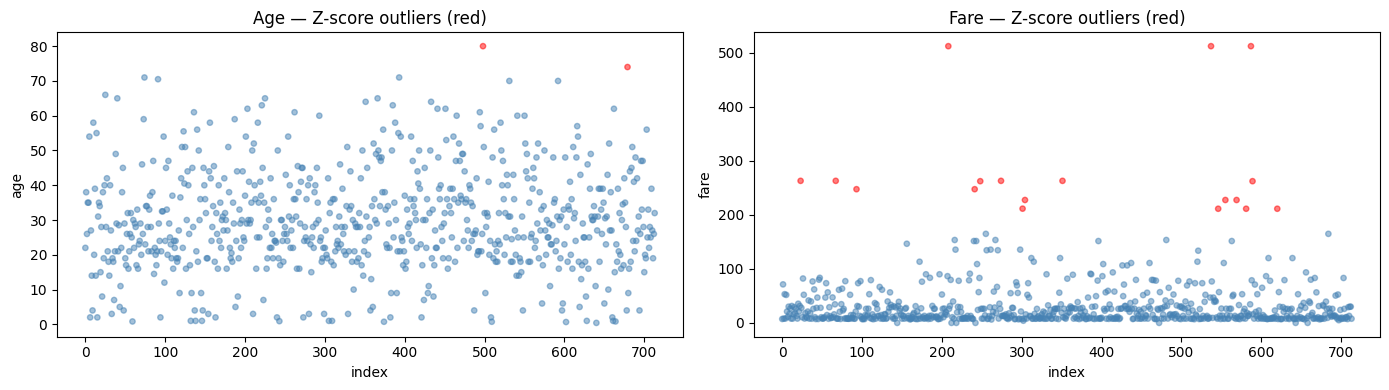

In [6]:
# Scatter plot: highlight Z-score outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (col, z_col), color_col in [
    (axes[0], ('age', 'age_z'), 'age_z'),
    (axes[1], ('fare', 'fare_z'), 'fare_z')
]:
    colors = df_clean[z_col].apply(lambda z: 'red' if z > 3 else 'steelblue')
    ax.scatter(range(len(df_clean)), df_clean[col], c=colors, alpha=0.5, s=15)
    ax.set_title(f'{col.capitalize()} — Z-score outliers (red)')
    ax.set_ylabel(col)
    ax.set_xlabel('index')

plt.tight_layout()
plt.show()

### Detection Method 2: IQR Method

Robust to non-normal distributions. Uses the interquartile range as a reference:

$$\text{Lower fence} = Q1 - 1.5 \times IQR$$
$$\text{Upper fence} = Q3 + 1.5 \times IQR$$

Points outside these fences are flagged as outliers. This is exactly what boxplot whiskers show.

In [7]:
def iqr_outlier_info(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return Q1, Q3, IQR, lower, upper, outliers

for col in ['age', 'fare']:
    Q1, Q3, IQR, lower, upper, outliers = iqr_outlier_info(df[col].dropna())
    print(f"{col.upper()}")
    print(f"  Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
    print(f"  Fences: [{lower:.1f}, {upper:.1f}]")
    print(f"  Outliers: {len(outliers)} (range: {outliers.min():.1f} to {outliers.max():.1f})")
    print()

AGE
  Q1=20.1, Q3=38.0, IQR=17.9
  Fences: [-6.7, 64.8]
  Outliers: 11 (range: 65.0 to 80.0)

FARE
  Q1=7.9, Q3=31.0, IQR=23.1
  Fences: [-26.7, 65.6]
  Outliers: 116 (range: 66.6 to 512.3)



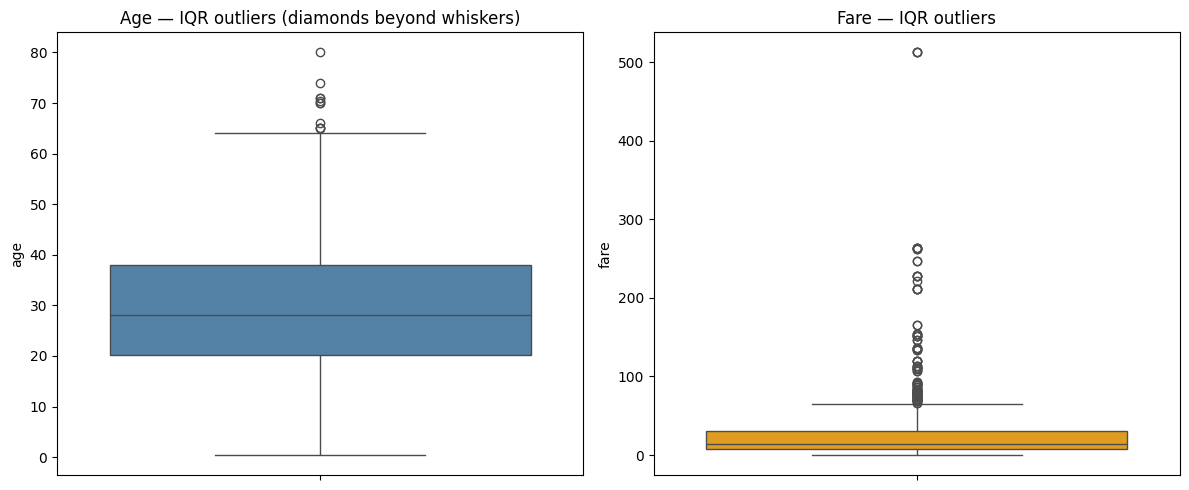

In [8]:
# Boxplot highlights IQR outliers automatically
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['age'].dropna(),  ax=axes[0], color='steelblue')
axes[0].set_title('Age — IQR outliers (diamonds beyond whiskers)')

sns.boxplot(y=df['fare'].dropna(), ax=axes[1], color='orange')
axes[1].set_title('Fare — IQR outliers')

plt.tight_layout()
plt.show()

### Handling Outliers

| Strategy | Method | When |
|---|---|---|
| **Remove** | Drop the row | True errors; very few outliers |
| **Cap (Winsorise)** | Clip at fence values | Preserve all rows; reduce extreme impact |
| **Transform** | Log, sqrt | Reduce skew; compress the scale |
| **Keep** | Do nothing | Outlier is real and meaningful |

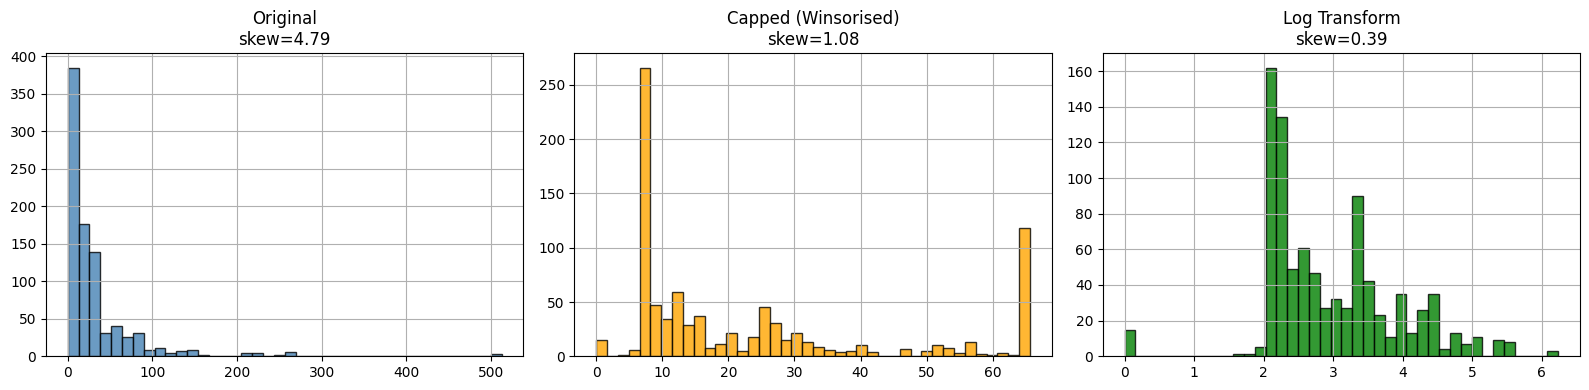

In [9]:
df_handle = df[['fare']].dropna().copy()
Q1, Q3, IQR, lower, upper, _ = iqr_outlier_info(df_handle['fare'])

df_handle['fare_capped'] = df_handle['fare'].clip(lower=lower, upper=upper)
df_handle['fare_log']    = np.log1p(df_handle['fare'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title, color in [
    (axes[0], 'fare',        'Original',              'steelblue'),
    (axes[1], 'fare_capped', 'Capped (Winsorised)',    'orange'),
    (axes[2], 'fare_log',    'Log Transform',          'green'),
]:
    df_handle[col].hist(bins=40, ax=ax, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(f'{title}\nskew={df_handle[col].skew():.2f}')

plt.tight_layout()
plt.show()

## Key Takeaways

| Issue | Detection | Fix |
|---|---|---|
| Duplicates | `duplicated().sum()` | `drop_duplicates(keep='first')` |
| Outliers (normal dist.) | Z-score \|z\| > 3 | Remove / cap / transform |
| Outliers (skewed dist.) | IQR fences | Remove / cap / transform |

- Z-score assumes normality; IQR is distribution-agnostic
- Always check if the outlier is a real signal before removing it